# Routing

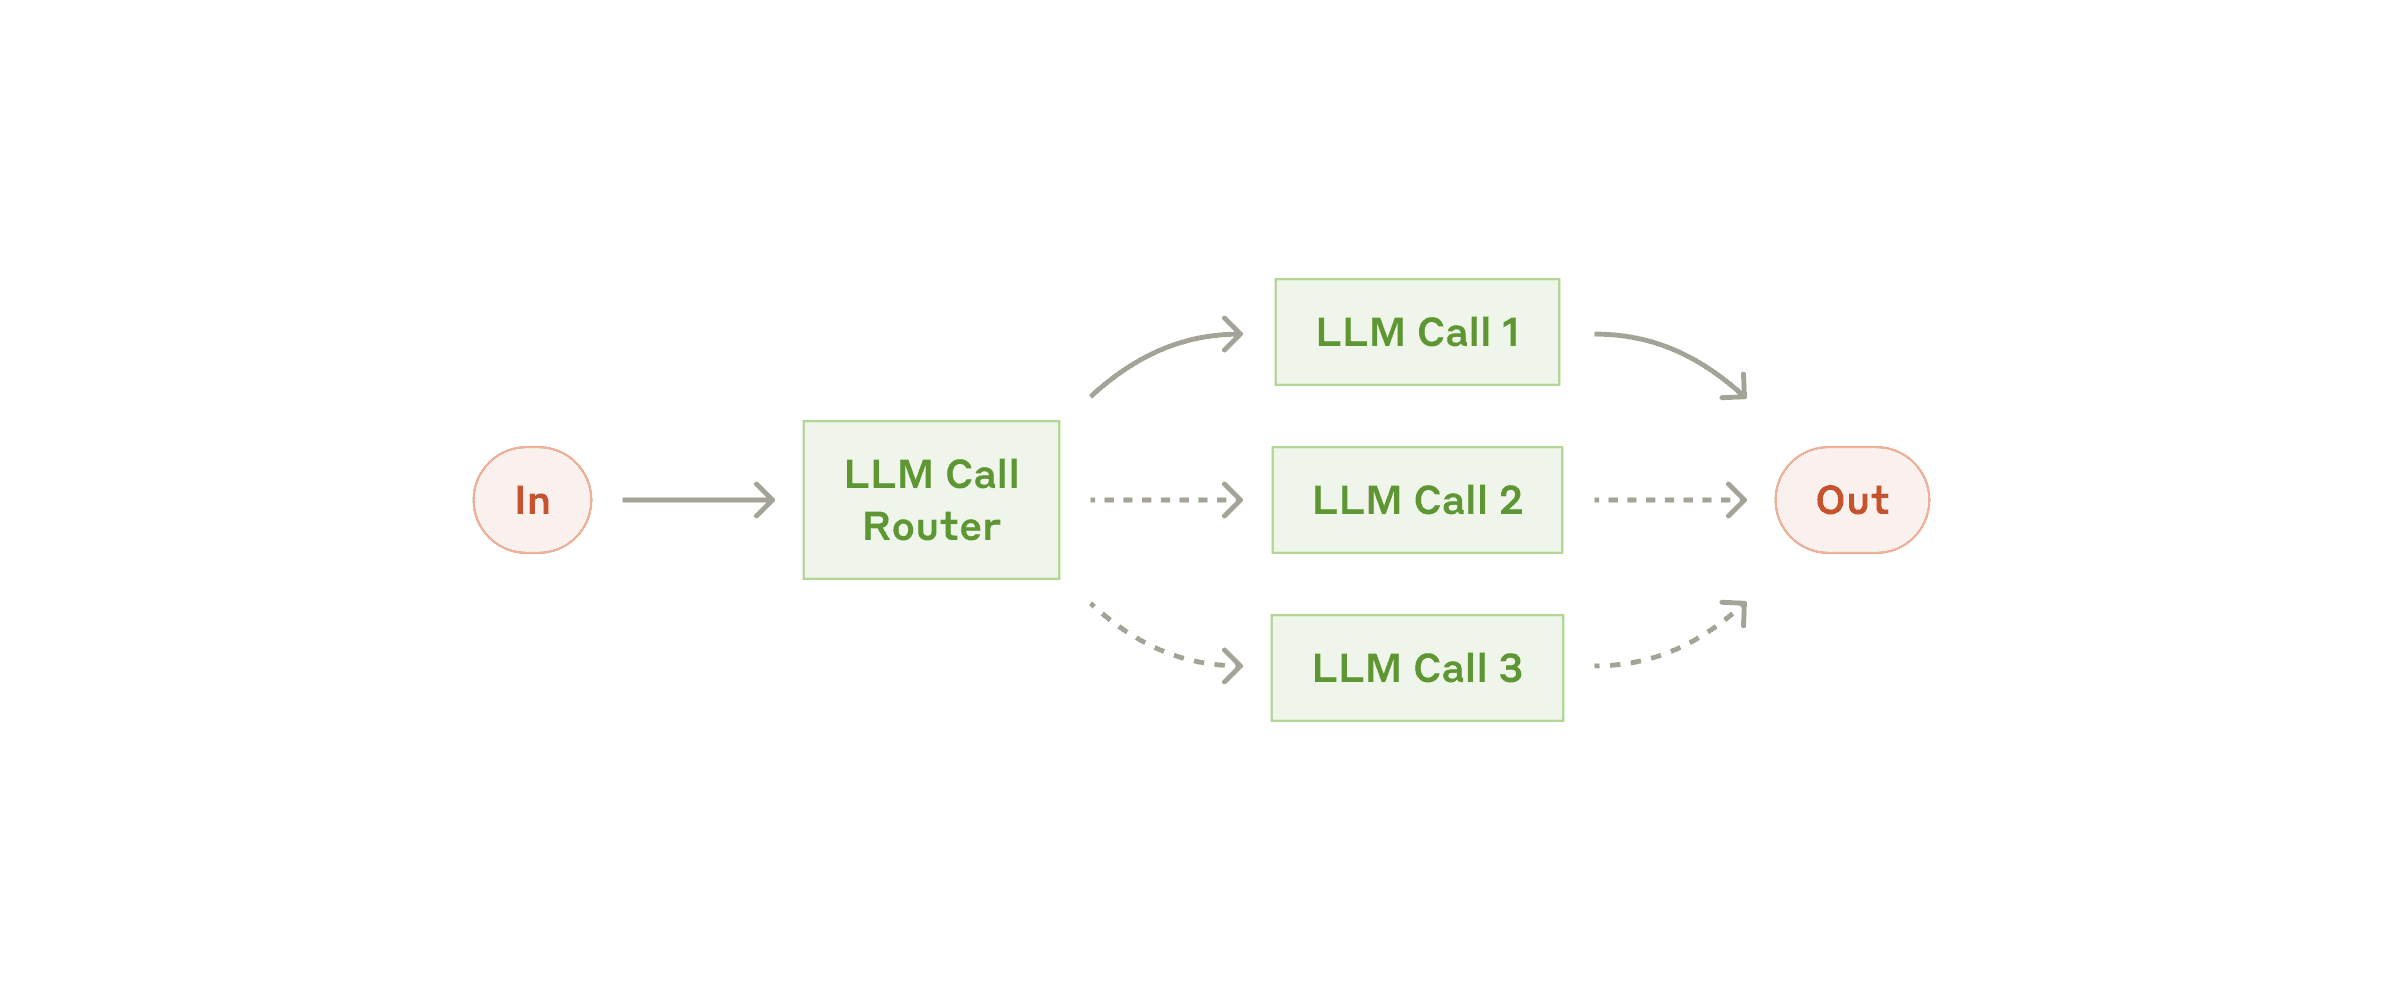

Eg. If you want to make new event or modify existing one

Like Prompt Chaining but instead of stoping at Gate, we route it to different llm call

In [4]:
from typing import Optional, Literal
from pydantic import BaseModel, Field
from openai import OpenAI
import os
import logging

In [5]:
# Set up logging configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

In [6]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
model = "gpt-4o-mini"

In [7]:
# Pydantic Models
class CalendarRequestType(BaseModel):
    """Router LLM call: Determine the type of calendar request"""

    request_type: Literal["new_event", "modify_event", "other"] = Field(
        description="Type of calendar request being made"
    )
    confidence_score: float = Field(description="Confidence score between 0 and 1")
    description: str = Field(description="Cleaned description of the request")


class NewEventDetails(BaseModel):
    """Details for creating a new event"""

    name: str = Field(description="Name of the event")
    date: str = Field(description="Date and time of the event (ISO 8601)")
    duration_minutes: int = Field(description="Duration in minutes")
    participants: list[str] = Field(description="List of participants")


class Change(BaseModel):
    """Details for changing an existing event"""

    field: str = Field(description="Field to change")
    new_value: str = Field(description="New value for the field")


class ModifyEventDetails(BaseModel):
    """Details for modifying an existing event"""

    event_identifier: str = Field(
        description="Description to identify the existing event"
    )
    changes: list[Change] = Field(description="List of changes to make")
    participants_to_add: list[str] = Field(description="New participants to add")
    participants_to_remove: list[str] = Field(description="Participants to remove")


class CalendarResponse(BaseModel):
    """Final response format"""

    success: bool = Field(description="Whether the operation was successful")
    message: str = Field(description="User-friendly response message")
    calendar_link: Optional[str] = Field(description="Calendar link if applicable")


In [8]:
# Define routing and processing functions
def route_calendar_request(user_input: str) -> CalendarRequestType:
    """Router LLM call to determine the type of calendar request"""
    logger.info("Routing calendar request")

    completion = client.beta.chat.completions.parse(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "Determine if this is a request to create a new calendar event or modify an existing one.",
            },
            {"role": "user", "content": user_input},
        ],
        response_format=CalendarRequestType,
    )
    result = completion.choices[0].message.parsed
    logger.info(
        f"Request routed as: {result.request_type} with confidence: {result.confidence_score}"
    )
    return result

In [9]:
def handle_new_event(description: str) -> CalendarResponse:
    """Process a new event request"""
    logger.info("Processing new event request")

    # Get event details
    completion = client.beta.chat.completions.parse(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "Extract details for creating a new calendar event.",
            },
            {"role": "user", "content": description},
        ],
        response_format=NewEventDetails,
    )
    details = completion.choices[0].message.parsed

    logger.info(f"New event: {details.model_dump_json(indent=2)}")

    # Generate response
    return CalendarResponse(
        success=True,
        message=f"Created new event '{details.name}' for {details.date} with {', '.join(details.participants)}",
        calendar_link=f"calendar://new?event={details.name}",
    )

In [10]:
def handle_modify_event(description: str) -> CalendarResponse:
    """Process an event modification request"""
    logger.info("Processing event modification request")

    # Get modification details
    completion = client.beta.chat.completions.parse(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "Extract details for modifying an existing calendar event.",
            },
            {"role": "user", "content": description},
        ],
        response_format=ModifyEventDetails,
    )
    details = completion.choices[0].message.parsed

    logger.info(f"Modified event: {details.model_dump_json(indent=2)}")

    # Generate response
    return CalendarResponse(
        success=True,
        message=f"Modified event '{details.event_identifier}' with the requested changes",
        calendar_link=f"calendar://modify?event={details.event_identifier}",
    )

In [ ]:
# Main Function
def process_calendar_request(user_input: str) -> Optional[CalendarResponse]:
    logger.info("Processing calendar request")

    # Route the request
    route_result = route_calendar_request(user_input)

    # Check confidence threshold
    if route_result.confidence_score < 0.7:
        logger.warning(f"Low confidence score: {route_result.confidence_score}")
        return None

    # Route to appropriate handler
    if route_result.request_type == "new_event":
        return handle_new_event(route_result.description)
    elif route_result.request_type == "modify_event":
        return handle_modify_event(route_result.description)
    else:
        logger.warning("Request type not supported")
        return None

In [12]:
# new event
new_event_input = "Let's schedule a team meeting next Tuesday at 2pm with Alice and Bob"
result = process_calendar_request(new_event_input)
if result:
    print(f"Response: {result.message}")

2026-05-11 19:52:08 - INFO - Processing calendar request
2026-05-11 19:52:08 - INFO - Routing calendar request
2026-05-11 19:52:12 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-11 19:52:12 - INFO - Request routed as: new_event with confidence: 0.95
2026-05-11 19:52:12 - INFO - Processing new event request
2026-05-11 19:52:14 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-11 19:52:14 - INFO - New event: {
  "name": "Team Meeting",
  "date": "2023-10-31T14:00:00Z",
  "duration_minutes": 60,
  "participants": [
    "Alice",
    "Bob"
  ]
}


Response: Created new event 'Team Meeting' for 2023-10-31T14:00:00Z with Alice, Bob


In [13]:
# modify event
modify_event_input = (
    "Can you move the team meeting with Alice and Bob to Wednesday at 3pm instead?"
)
result = process_calendar_request(modify_event_input)
if result:
    print(f"Response: {result.message}")

2026-05-11 19:52:24 - INFO - Processing calendar request
2026-05-11 19:52:24 - INFO - Routing calendar request
2026-05-11 19:52:26 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-11 19:52:26 - INFO - Request routed as: modify_event with confidence: 0.95
2026-05-11 19:52:26 - INFO - Processing event modification request
2026-05-11 19:52:28 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-11 19:52:28 - INFO - Modified event: {
  "event_identifier": "Team meeting with Alice and Bob",
  "changes": [
    {
      "field": "date",
      "new_value": "Wednesday"
    },
    {
      "field": "time",
      "new_value": "3pm"
    }
  ],
  "participants_to_add": [],
  "participants_to_remove": []
}


Response: Modified event 'Team meeting with Alice and Bob' with the requested changes


In [14]:
# invalid input

invalid_input = "What's the weather like today?"
result = process_calendar_request(invalid_input)
if not result:
    print("Request not recognized as a calendar operation")

2026-05-11 19:52:58 - INFO - Processing calendar request
2026-05-11 19:52:58 - INFO - Routing calendar request
2026-05-11 19:53:01 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-11 19:53:01 - INFO - Request routed as: other with confidence: 0.9
2026-05-11 19:53:01 - WARNING - Request type not supported


Request not recognized as a calendar operation
